# SVM para predecir % Silica Concentrate

Modelo SVR entrenado unicamente con las variables de entrada en las que los
3 metodos wrapper (BSFS backward, RFE lineal, RFE RandomForest) de
`data_preprocessing.ipynb` coinciden en que aportan (`n_methods_agree == 3`
en `wrapper_comparison`).

Reglas seguidas (coherentes con `data_preprocessing.ipynb`):
- Split cronologico 80/20 train/test, nunca aleatorio (serie temporal).
- Ajuste de hiperparametros via `TimeSeriesSplit` dentro del train (no CV
  aleatoria, evita fuga de informacion futura -> pasado).
- Metrica: RMSE + residual plot, nunca solo R².
- Los outputs (`% Silica Concentrate` incluido) nunca se usan como feature
  de entrada de otro modelo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CSV exportado por data_preprocessing.ipynb. Ya viene a resolucion horaria, sin el
# hueco de 13 dias, sin las columnas Flotation Column ni % Iron Concentrate, y con
# una columna 'split' (train/val/test cronologico). Por eso aqui NO se reparten
# timestamps, ni se recorta, ni se remuestrea (el resample().mean() fallaba al
# intentar promediar la columna de texto 'split').
# Con skewness corregido: ..._preprocessed_h.csv | sin corregir: ..._noskew.csv
# Con Flotation Column: ..._preprocessed_h_flotcols_noskew.csv | sin ellas: ..._preprocessed_h_noskew.csv
filepath = '../Datasets/MiningProcess_Flotation_preprocessed_h_flotcols_noskew.csv'

df = pd.read_csv(filepath, parse_dates=['date'], index_col='date')
split_col = df.pop('split')          # etiqueta de split del preproceso; fuera de las features

lab_cols = ['% Iron Feed', '% Silica Feed', '% Silica Concentrate']
sensor_cols = [c for c in df.columns if c not in lab_cols]
# Rango del escalado Min-Max (ajustado solo con train). Usar (0.05, 0.95) en vez de (0, 1)
# deja margen para que val/test tomen valores algo mayores/menores que los vistos en train.
SCALE_RANGE = (0.2, 0.8)
df_raw = df   # alias: el resto del notebook usa df_raw/df
print(f'{df.shape[0]:,} filas, {df.index.min()} -> {df.index.max()}')
print('sensor_cols:', sensor_cols)


## Seleccion de features: reproducir wrapper_comparison de data_preprocessing.ipynb

Se recalculan aqui los 3 metodos wrapper (BSFS backward, RFE lineal, RFE
RandomForest) para obtener las variables donde los 3 coinciden, en vez de
depender de ejecutar el otro notebook antes que este.

In [ ]:
vs_feature_cols = sensor_cols
vs_target_col = '% Silica Concentrate'
# Se elige la mitad de las candidatas (debe ser < n. de candidatas)
N_SELECT = len(vs_feature_cols) // 2
print(f'{len(vs_feature_cols)} candidatas, se seleccionan {N_SELECT} por metodo')


VSdata_df = df[[vs_target_col] + vs_feature_cols].dropna()
X_vs = VSdata_df[vs_feature_cols].to_numpy()
y_vs = VSdata_df[vs_target_col].to_numpy()

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector, RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

xscaler_vs = MinMaxScaler(feature_range=SCALE_RANGE)
X_vs_scaled = xscaler_vs.fit_transform(X_vs)
yscaler_vs = MinMaxScaler(feature_range=SCALE_RANGE)
y_vs_scaled = yscaler_vs.fit_transform(y_vs[:, None])

# BSFS (backward, lineal)
BSFS = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=N_SELECT, direction='backward', cv=5
).fit(X_vs_scaled, y_vs_scaled)
bsfs_selected_names = [vs_feature_cols[i] for i in BSFS.get_support(indices=True)]

# RFE lineal
rfe_model = RFE(LinearRegression(), n_features_to_select=N_SELECT).fit(X_vs_scaled, y_vs_scaled)
rfe_selected_names = [vs_feature_cols[i] for i in rfe_model.get_support(indices=True)]

# RFE RandomForest (no lineal, sin escalar: los arboles son invariantes a escala)
rfe_rf_model = RFE(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    n_features_to_select=N_SELECT,
).fit(X_vs, y_vs)
rfe_rf_selected_names = [vs_feature_cols[i] for i in rfe_rf_model.get_support(indices=True)]

all_features = set(bsfs_selected_names) | set(rfe_selected_names) | set(rfe_rf_selected_names)
wrapper_comparison = pd.DataFrame({'feature': sorted(all_features)})
wrapper_comparison['BSFS_linear'] = wrapper_comparison['feature'].isin(bsfs_selected_names)
wrapper_comparison['RFE_linear'] = wrapper_comparison['feature'].isin(rfe_selected_names)
wrapper_comparison['RFE_random_forest'] = wrapper_comparison['feature'].isin(rfe_rf_selected_names)
wrapper_comparison['n_methods_agree'] = wrapper_comparison[
    ['BSFS_linear', 'RFE_linear', 'RFE_random_forest']
].sum(axis=1)
wrapper_comparison = wrapper_comparison.sort_values('n_methods_agree', ascending=False).reset_index(drop=True)

svm_feature_cols = wrapper_comparison.loc[wrapper_comparison['n_methods_agree'] == 3, 'feature'].tolist()
print(f'Features donde coinciden los 3 metodos ({len(svm_feature_cols)}): {svm_feature_cols}')
wrapper_comparison

## Excluir tramos estaticos del target

Ver `data_preprocessing.ipynb`, seccion "Missing data handle": % Silica
Concentrate se queda en un valor EXACTAMENTE igual durante varias lecturas
seguidas en ciertos tramos (posible artefacto de muestreo de laboratorio,
no dinamica real del proceso). Se excluyen del dataset de modelado las
filas que caen en un tramo estatico de mas de 1 dia, para no entrenar ni
evaluar el modelo contra "ruido" de no-medicion disfrazado de valor real.

In [24]:
static_min_days = 1

def find_static_runs(series, min_days):
    """Devuelve un DataFrame con los tramos (inicio, fin, valor, duracion)
    donde `series` se mantiene EXACTAMENTE igual durante >= min_days."""
    s = series.dropna().sort_index()
    run_id = (s != s.shift()).cumsum()

    runs = []
    for _, group in s.groupby(run_id):
        duration = group.index.max() - group.index.min()
        if duration >= pd.Timedelta(days=min_days):
            runs.append({
                'start': group.index.min(),
                'end': group.index.max(),
                'value': group.iloc[0],
                'duration_days': duration.total_seconds() / 86400,
                'n_readings': len(group),
            })

    return pd.DataFrame(runs).sort_values('duration_days', ascending=False) if runs else pd.DataFrame(
        columns=['start', 'end', 'value', 'duration_days', 'n_readings']
    )

static_runs_target = find_static_runs(df[vs_target_col], static_min_days)
print(f'Tramos estaticos en {vs_target_col} (>= {static_min_days} dia): {len(static_runs_target)}')
print(static_runs_target)

# Mascara de filas a excluir: cualquier timestamp dentro de [start, end] de
# algun tramo estatico
static_mask = pd.Series(False, index=df.index)
for _, row in static_runs_target.iterrows():
    static_mask |= (df.index >= row['start']) & (df.index <= row['end'])

n_excluded = static_mask.sum()
print(f'\nFilas excluidas por estar en tramo estatico: {n_excluded} de {len(df)} '
      f'({n_excluded / len(df) * 100:.2f}%)')

Tramos estaticos en % Silica Concentrate (>= 1 dia): 3
                start                 end  value  duration_days  n_readings
1 2017-07-31 20:00:00 2017-08-03 20:00:00   2.08       3.000000          73
0 2017-03-31 17:00:00 2017-04-02 07:00:00   3.11       1.583333          39
2 2017-08-17 02:00:00 2017-08-18 05:00:00   1.19       1.125000          28

Filas excluidas por estar en tramo estatico: 140 de 4097 (3.42%)


## Split temporal 70/20/10 y escalado

Split cronologico (no aleatorio): primer 70% train, siguiente 20% val
(para elegir hiperparametros), ultimo 10% test (evaluacion final, nunca
tocado hasta el final). El escalado (MAD, robusto a outliers, coherente
con el resto del proyecto) se ajusta SOLO con train para evitar fuga de
informacion del futuro (val/test) hacia el pasado (train).

In [25]:
svm_data = df[svm_feature_cols + [vs_target_col]].dropna().sort_index()

# Excluir filas en tramos estaticos del target (celda anterior)
svm_data = svm_data.loc[~static_mask.reindex(svm_data.index, fill_value=False)]
print(f'svm_data tras excluir tramos estaticos: {len(svm_data)} filas')

n_total = len(svm_data)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.9)

train_data = svm_data.iloc[:n_train]
val_data = svm_data.iloc[n_train:n_val]
test_data = svm_data.iloc[n_val:]

print(f'Train: {len(train_data)} filas ({train_data.index.min()} -> {train_data.index.max()})')
print(f'Val:   {len(val_data)} filas ({val_data.index.min()} -> {val_data.index.max()})')
print(f'Test:  {len(test_data)} filas ({test_data.index.min()} -> {test_data.index.max()})')

X_train_raw = train_data[svm_feature_cols]
y_train = train_data[vs_target_col].to_numpy()
X_val_raw = val_data[svm_feature_cols]
y_val = val_data[vs_target_col].to_numpy()
X_test_raw = test_data[svm_feature_cols]
y_test = test_data[vs_target_col].to_numpy()

from scipy.stats import median_abs_deviation
from sklearn.preprocessing import MinMaxScaler

# Min-Max a SCALE_RANGE (0.1-0.9) ajustado SOLO con train (val/test nunca deben
# influir en el escalado). El margen hasta 0 y 1 permite que val/test superen el
# maximo (o bajen del minimo) de train sin salirse de [0, 1].
xscaler = MinMaxScaler(feature_range=SCALE_RANGE).fit(X_train_raw)
X_train = xscaler.transform(X_train_raw)
X_val = xscaler.transform(X_val_raw)
X_test = xscaler.transform(X_test_raw)

yscaler = MinMaxScaler(feature_range=SCALE_RANGE).fit(y_train[:, None])
y_train_scaled = yscaler.transform(y_train[:, None]).ravel()
y_val_scaled = yscaler.transform(y_val[:, None]).ravel()

svm_data tras excluir tramos estaticos: 3957 filas
Train: 2769 filas (2017-03-10 01:00:00 -> 2017-07-18 06:00:00)
Val:   792 filas (2017-07-18 07:00:00 -> 2017-08-24 11:00:00)
Test:  396 filas (2017-08-24 12:00:00 -> 2017-09-09 23:00:00)


## Ajuste de hiperparametros: grid search contra el holdout de validacion

En vez de CV dentro de train, se usa el 20% de val como holdout unico: se
entrena cada combinacion del grid SOLO con train y se evalua (RMSE) contra
val, quedandose con la mejor. Val actua como un unico corte temporal
posterior a train (nunca aleatorio), y test queda intacto hasta el final.

In [26]:
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error
from itertools import product

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5],
}

param_names = list(param_grid.keys())
grid_results = []

for combo in product(*param_grid.values()):
    params = dict(zip(param_names, combo))
    model = SVR(kernel='rbf', **params).fit(X_train, y_train_scaled)

    val_pred_scaled = model.predict(X_val)
    val_pred = yscaler.inverse_transform(val_pred_scaled[:, None]).ravel()  # deshacer escalado para RMSE en unidades reales
    val_rmse = root_mean_squared_error(y_val, val_pred)

    grid_results.append({**params, 'val_rmse': val_rmse})

grid_results_df = pd.DataFrame(grid_results).sort_values('val_rmse').reset_index(drop=True)
print(grid_results_df.head(10))

best_params = grid_results_df.iloc[0][param_names].to_dict()
print('\nMejores hiperparametros (por RMSE en val):', best_params)

svm_model = SVR(kernel='rbf', **best_params).fit(X_train, y_train_scaled)

       C  gamma  epsilon  val_rmse
0   10.0    0.1      0.1  1.061981
1    0.1      1      0.1  1.064604
2  100.0    0.1      0.1  1.065640
3    1.0      1      0.1  1.067895
4  100.0   0.01      0.1  1.069432
5    1.0    0.1      0.1  1.072262
6   10.0   0.01      0.1  1.074215
7   10.0      1      0.1  1.078590
8    0.1  scale      0.1  1.079668
9  100.0      1      0.1  1.084007

Mejores hiperparametros (por RMSE en val): {'C': 10.0, 'gamma': 0.1, 'epsilon': 0.1}


## Evaluacion en test: RMSE + residual plot

Las predicciones se deshacen a la escala original (% Silica Concentrate)
antes de calcular el RMSE, para que sea interpretable en unidades reales
y comparable con otros modelos. Nunca se reporta solo R².

RMSE (test, % Silica Concentrate): 1.1319
R² (test, solo como referencia):   0.0884


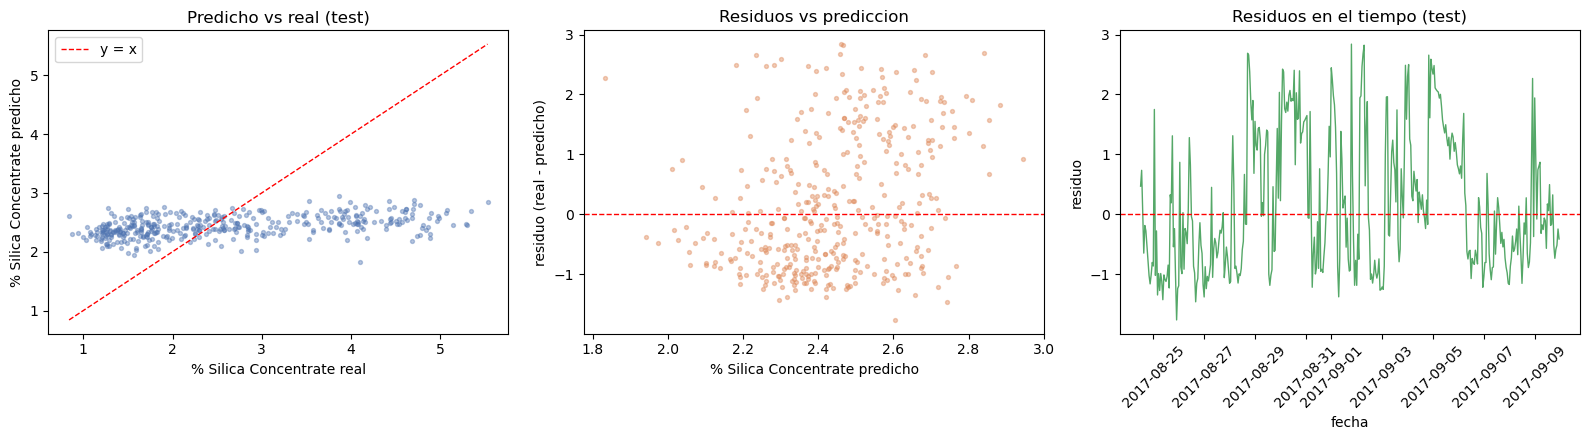

In [27]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred_scaled = svm_model.predict(X_test)
y_pred = yscaler.inverse_transform(y_pred_scaled[:, None]).ravel()  # deshacer Min-Max -> unidades originales

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # se reporta solo como referencia adicional, no como metrica principal

print(f'RMSE (test, % Silica Concentrate): {rmse:.4f}')
print(f'R² (test, solo como referencia):   {r2:.4f}')

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Predicho vs real
axes[0].scatter(y_test, y_pred, s=8, alpha=0.4, color='#4C72B0')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')
axes[0].set_xlabel('% Silica Concentrate real')
axes[0].set_ylabel('% Silica Concentrate predicho')
axes[0].set_title('Predicho vs real (test)')
axes[0].legend()

# Residuos vs predicho (buscar heterocedasticidad o sesgo)
axes[1].scatter(y_pred, residuals, s=8, alpha=0.4, color='#DD8452')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('% Silica Concentrate predicho')
axes[1].set_ylabel('residuo (real - predicho)')
axes[1].set_title('Residuos vs prediccion')

# Residuos en el tiempo (buscar deriva/degradacion del modelo)
axes[2].plot(test_data.index, residuals, color='#55A868', linewidth=1)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('fecha')
axes[2].set_ylabel('residuo')
axes[2].set_title('Residuos en el tiempo (test)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

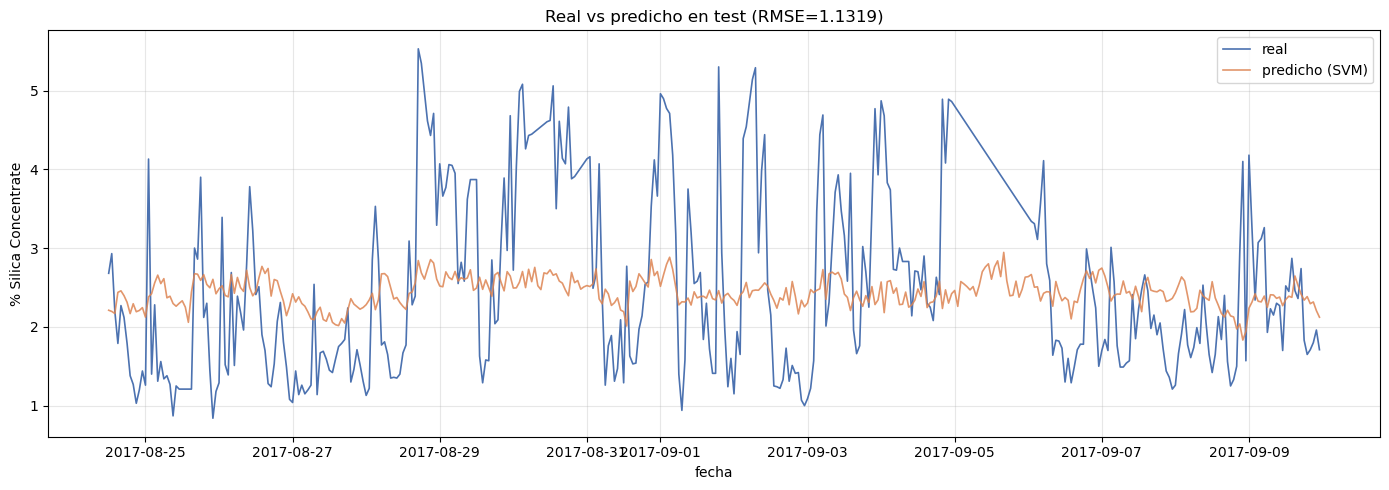

In [28]:
# Serie temporal: real vs predicho sobre el conjunto de test (timestamp en el
# eje X, convencion del proyecto).
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_data.index, y_test, label='real', color='#4C72B0', linewidth=1.2)
ax.plot(test_data.index, y_pred, label='predicho (SVM)', color='#DD8452', linewidth=1.2, alpha=0.85)
ax.set_xlabel('fecha')
ax.set_ylabel('% Silica Concentrate')
ax.set_title(f'Real vs predicho en test (RMSE={rmse:.4f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Baseline de referencia

Un RMSE aislado no dice si el modelo aporta algo. Se compara contra dos
baselines triviales: predecir siempre la mediana del train, y predecir el
ultimo valor conocido (persistencia, "naive forecast").

In [29]:
# Baseline 1: predecir siempre la mediana del train
baseline_median_pred = np.full_like(y_test, fill_value=np.median(y_train))
rmse_median = root_mean_squared_error(y_test, baseline_median_pred)

# Baseline 2: persistencia (predecir el valor de la lectura anterior, y[t-1])
y_full = svm_data[vs_target_col].to_numpy()
y_test_prev = y_full[n_val - 1:n_total - 1]  # valor anterior a cada punto de test
rmse_naive = root_mean_squared_error(y_test, y_test_prev)

baseline_summary = pd.DataFrame({
    'modelo': ['SVM (RBF)', 'Baseline: mediana train', 'Baseline: persistencia (t-1)'],
    'RMSE': [rmse, rmse_median, rmse_naive],
}).sort_values('RMSE')

baseline_summary

,modelo,RMSE
2,Baseline: persistencia (t-1),0.789390
0,SVM (RBF),1.131947
1,Baseline: mediana train,1.360409


## DIAGNOSTICO (no evaluacion real): split aleatorio con shuffle

**Esto NO sustituye el split temporal de arriba.** Es solo para comprobar si
la tendencia del SVM a "tirar a la media" en los picos es un artefacto del
split cronologico (val/test cae en un tramo de la campaña con una
distribucion de picos distinta a train) o una limitacion real del modelo/
features.

Aviso: con `shuffle=True` en una serie temporal muestreada cada hora, val/test
pueden contener vecinos temporales inmediatos de filas usadas en train (t-1,
t+1 están muy correlacionados). Eso filtra informacion y el RMSE que salga
aqui sera optimista, no comparable con el RMSE del split temporal. Sirve
solo para ver si el patron de "aplastar los picos" persiste o desaparece.

Train: 2769, Val: 792, Test: 396
Mejores hiperparametros (shuffle): {'C': 1.0, 'gamma': 'scale', 'epsilon': 0.1}
RMSE test (shuffle, DIAGNOSTICO, no comparable al split temporal): 1.0751


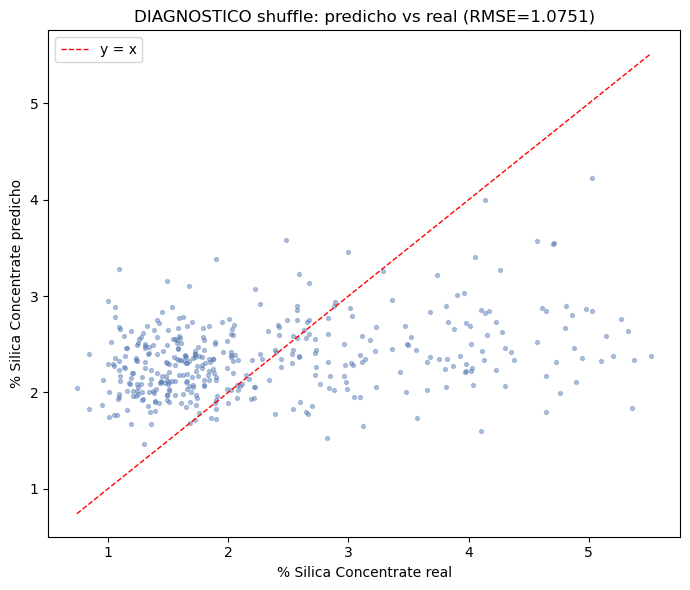

In [30]:
from sklearn.model_selection import train_test_split

X_shuf = svm_data[svm_feature_cols]
y_shuf = svm_data[vs_target_col].to_numpy()

# 70/20/10 pero con shuffle=True (por defecto en train_test_split)
X_shuf_train_raw, X_shuf_temp_raw, y_shuf_train, y_shuf_temp = train_test_split(
    X_shuf, y_shuf, test_size=0.3, random_state=42
)
X_shuf_val_raw, X_shuf_test_raw, y_shuf_val, y_shuf_test = train_test_split(
    X_shuf_temp_raw, y_shuf_temp, test_size=1 / 3, random_state=42  # 1/3 de 30% = 10% del total
)

print(f'Train: {len(X_shuf_train_raw)}, Val: {len(X_shuf_val_raw)}, Test: {len(X_shuf_test_raw)}')

# Mismo MAD scaling, ajustado solo con train (aunque aqui "train" ya no es
# un bloque temporal limpio, se mantiene la misma disciplina de no tocar
# val/test al ajustar el escalador)
xscaler_shuf = MinMaxScaler(feature_range=SCALE_RANGE).fit(X_shuf_train_raw)
X_shuf_train = xscaler_shuf.transform(X_shuf_train_raw)
X_shuf_val = xscaler_shuf.transform(X_shuf_val_raw)
X_shuf_test = xscaler_shuf.transform(X_shuf_test_raw)

yscaler_shuf = MinMaxScaler(feature_range=SCALE_RANGE).fit(y_shuf_train[:, None])
y_shuf_train_scaled = yscaler_shuf.transform(y_shuf_train[:, None]).ravel()

# Mismo grid original (el que mejor funcionaba en el split temporal)
shuf_grid_results = []
for combo in product(*param_grid.values()):
    params = dict(zip(param_names, combo))
    model = SVR(kernel='rbf', **params).fit(X_shuf_train, y_shuf_train_scaled)

    val_pred = yscaler_shuf.inverse_transform(model.predict(X_shuf_val)[:, None]).ravel()
    val_rmse = root_mean_squared_error(y_shuf_val, val_pred)
    shuf_grid_results.append({**params, 'val_rmse': val_rmse})

shuf_grid_results_df = pd.DataFrame(shuf_grid_results).sort_values('val_rmse').reset_index(drop=True)
shuf_best_params = shuf_grid_results_df.iloc[0][param_names].to_dict()
print('Mejores hiperparametros (shuffle):', shuf_best_params)

shuf_svm_model = SVR(kernel='rbf', **shuf_best_params).fit(X_shuf_train, y_shuf_train_scaled)

shuf_test_pred = yscaler_shuf.inverse_transform(shuf_svm_model.predict(X_shuf_test)[:, None]).ravel()
shuf_test_rmse = root_mean_squared_error(y_shuf_test, shuf_test_pred)
print(f'RMSE test (shuffle, DIAGNOSTICO, no comparable al split temporal): {shuf_test_rmse:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_shuf_test, shuf_test_pred, s=8, alpha=0.4, color='#4C72B0')
lims = [min(y_shuf_test.min(), shuf_test_pred.min()), max(y_shuf_test.max(), shuf_test_pred.max())]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='y = x')
ax.set_xlabel('% Silica Concentrate real')
ax.set_ylabel('% Silica Concentrate predicho')
ax.set_title(f'DIAGNOSTICO shuffle: predicho vs real (RMSE={shuf_test_rmse:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

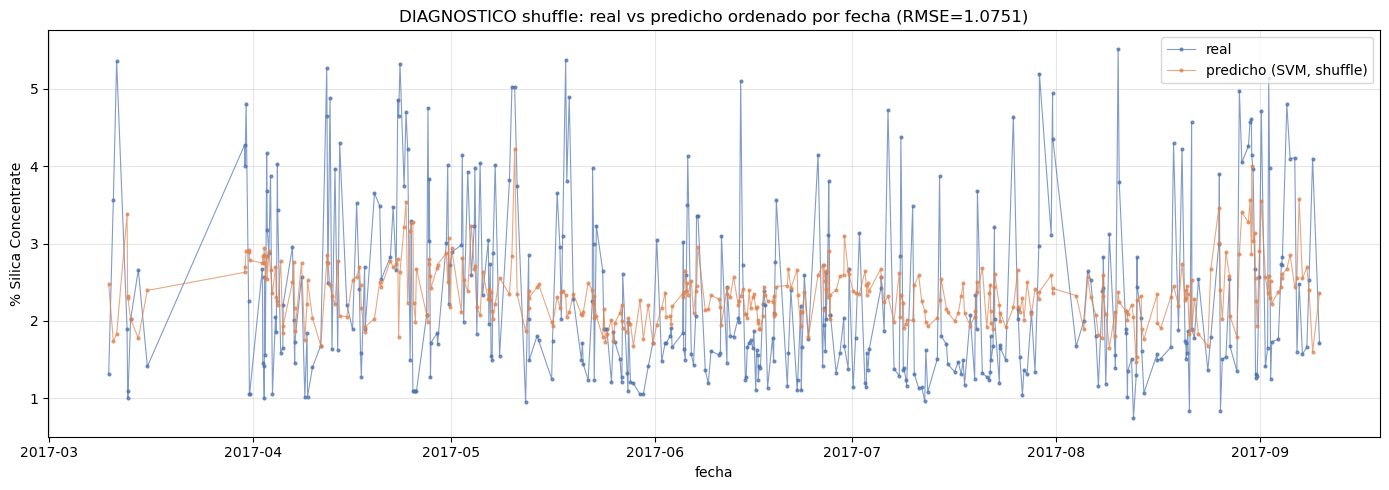

In [31]:
# Serie temporal del test con shuffle: los puntos de test estan dispersos por
# toda la campaña (no un tramo contiguo como en el split temporal), asi que
# se ordenan por fecha para que el eje X tenga sentido, pero el "hueco" entre
# puntos consecutivos es irregular (puede saltar dias). Util solo para ver si
# el patron de "aplastar los picos" se repite tambien aqui.
shuf_test_order = X_shuf_test_raw.index.argsort()
shuf_test_dates = X_shuf_test_raw.index[shuf_test_order]
shuf_y_test_sorted = y_shuf_test[shuf_test_order]
shuf_pred_sorted = shuf_test_pred[shuf_test_order]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shuf_test_dates, shuf_y_test_sorted, label='real', color='#4C72B0',
        linewidth=0.8, marker='o', markersize=2, alpha=0.7)
ax.plot(shuf_test_dates, shuf_pred_sorted, label='predicho (SVM, shuffle)', color='#DD8452',
        linewidth=0.8, marker='o', markersize=2, alpha=0.7)
ax.set_xlabel('fecha')
ax.set_ylabel('% Silica Concentrate')
ax.set_title(f'DIAGNOSTICO shuffle: real vs predicho ordenado por fecha (RMSE={shuf_test_rmse:.4f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()